<a href="https://colab.research.google.com/github/Kowshikh-10/Pytorch-/blob/main/CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install torchprofile 1>/dev/null

In [3]:
import random
from collections import OrderedDict, defaultdict

import numpy as np
import torch
from matplotlib import pyplot as plt
from torch import nn
from torch.optim import *
from torch.optim.lr_scheduler import *
from torch.utils.data import DataLoader
from torchprofile import profile_macs
from torchvision.datasets import *
from torchvision.transforms import *
from tqdm.auto import tqdm

In [4]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

In [5]:
# DATA 3x32x32
transforms = {
    "train" : Compose([
        RandomCrop(32, padding=4),
        RandomHorizontalFlip(),
        ToTensor(),
    ]),
    "test": ToTensor(),

}

dataset  = {}
for split in ["train", "test"]:
  dataset[split] = CIFAR10(
      root = "data/cifar10",
      train = (split == "train"),
      download = True,
      transform = transforms[split],
  )

100%|██████████| 170M/170M [01:06<00:00, 2.57MB/s]


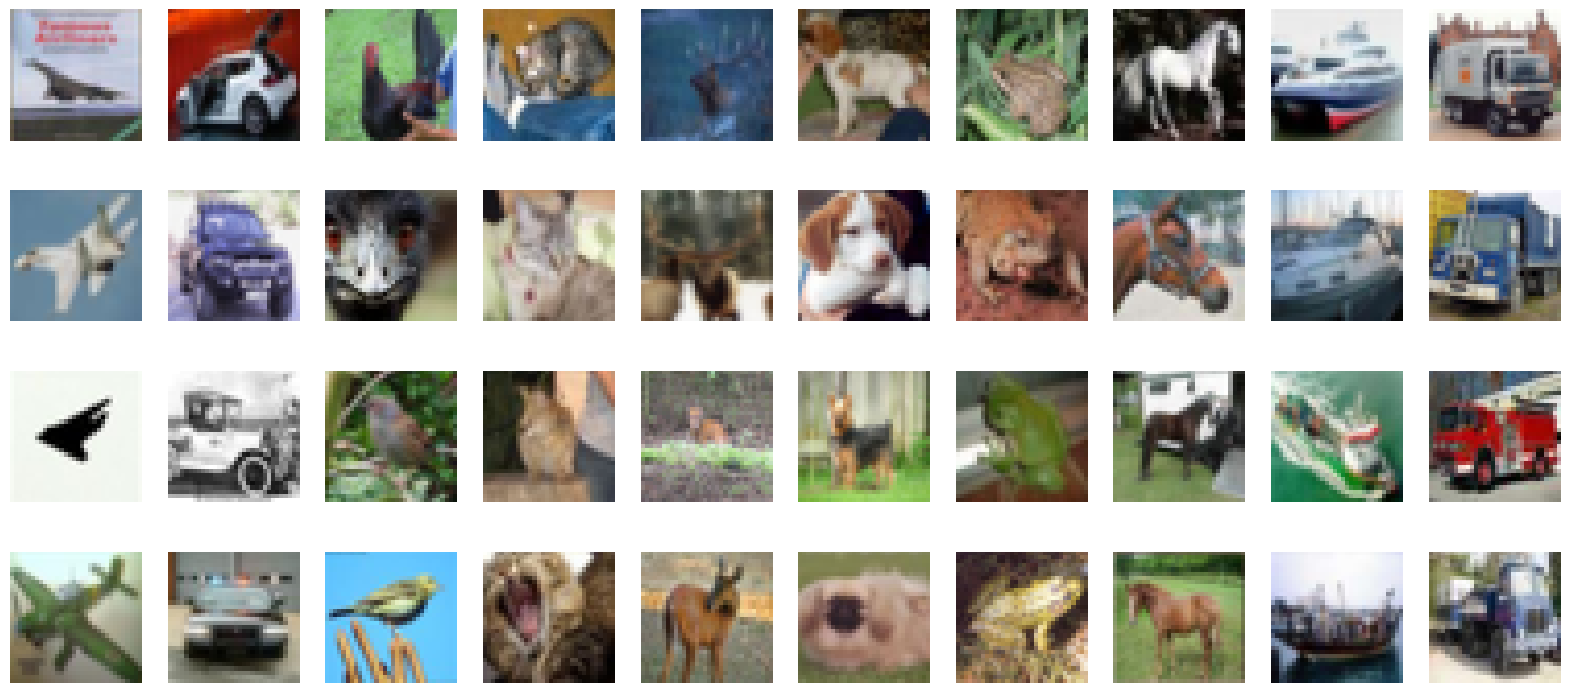

In [6]:
# we can visualize a few images
samples = [[] for _ in range(10)]
for image, label in dataset["test"]:
  if(len(samples[label])) < 4:
    samples[label].append(image)

plt.figure(figsize=(20,9))
for index in range(40):
  label = index % 10
  image = samples[label][index // 10]

  #convert from CHW to HWC for visualization
  image = image.permute(1,2,0)

  label = dataset["test"].classes[label]
  plt.subplot(4,10,index+1)
  plt.imshow(image)
  plt.axis("off")
plt.show()

In [7]:
# To train a neural network, we will need to feed data in batches , we create data loaders with batch size of
#512:

dataflow = {}
for split in ["train", "test"]:
  dataflow[split] = DataLoader(
      dataset[split],
      batch_size = 512,
      shuffle=(split == "train"),
      num_workers=0,
      pin_memory=True,
  )


In [8]:
for inputs, targets in dataflow["train"]:
  print("[inputs] dtype: {}, shape: {}".format(inputs.dtype, inputs.shape))
  print("[targets] dtype: {}, shape: {}".format(targets.dtype, targets.shape))
  break

[inputs] dtype: torch.float32, shape: torch.Size([512, 3, 32, 32])
[targets] dtype: torch.int64, shape: torch.Size([512])


Model

we are using VGG-11 with fewer downsamples and samller classifiers


In [9]:
class VGG(nn.Module):
  ARCH = [64, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']

  def __init__(self) -> None:
    super().__init__()

    layers = []
    counts = defaultdict(int)

    def add(name: str, layer: nn.Module) -> None:
      layers.append((f"{name}{counts[name]}", layer))
      counts[name] += 1

    in_channels = 3
    for x in self.ARCH:
      if x != 'M':
        # conv-bn-relu
        add("conv", nn.Conv2d(in_channels, x, 3, padding=1, bias=False))
        add("bn", nn.BatchNorm2d(x))
        add("relu", nn.ReLU(True))
        in_channels = x

      else:
        # maxpool
        add("pool", nn.MaxPool2d(2))

    self.backbone = nn.Sequential(OrderedDict(layers))
    self.classifier = nn.Linear(512, 10)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    # backbone: [N, 3, 32, 32] => [N, 512, 2, 2]
    x = self.backbone(x)

    # avgpool: [N, 512, 2, 2] => [N, 512]
    x = x.mean([2,3])
    # classifier: [N, 512] => [N, 10]
    x = self.classifier(x)
    return x

model = VGG().cuda()

In [10]:

print(model.backbone)


Sequential(
  (conv0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu0): ReLU(inplace=True)
  (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU(inplace=True)
  (pool0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU(inplace=True)
  (conv3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU(inplace=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilati

In [11]:
print(model.classifier)

Linear(in_features=512, out_features=10, bias=True)


The model size can be estimated by the number of trainable parameters:

In [12]:
num_params = 0
for param in model.parameters():
  if param.requires_grad:
    num_params += param.numel()
print("Params:", num_params)

Params: 9228362


The computation cost can be estimated by the number of multiply–accumulate operations (MACs) using TorchProfile:

In [13]:
num_macs = profile_macs(model, torch.zeros(1, 3, 32, 32).cuda())
print("MACs:", num_macs)

MACs: 606164480


This model has 9.2M parameters and requires 606M MACs for inference. We will work together in the next few labs to improve its efficiency.

Optimisation


As we are working on a classification problem, we will apply cross entropy as our loss function to optimize the model:

In [14]:
criterion = nn.CrossEntropyLoss()

Optimization will be carried out using stochastic gradient descent (SGD) with momentum:

In [15]:
optimizer = SGD(
  model.parameters(),
  lr=0.4,
  momentum=0.9,
  weight_decay=5e-4,
)

The learning rate will be modulated using the following scheduler

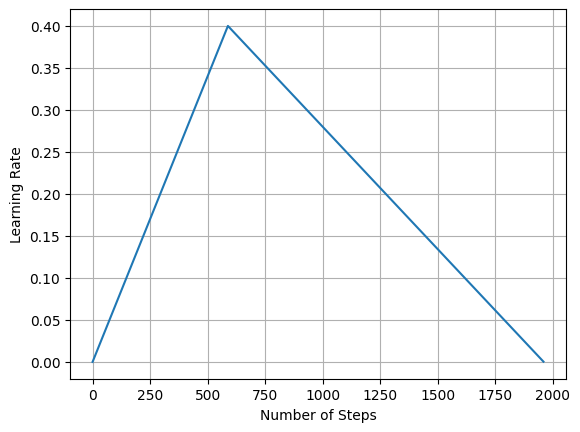

In [16]:
num_epochs = 20
steps_per_epoch = len(dataflow["train"])

#peicewise linear scheduler
lr_lambda = lambda step: np.interp(
    [step / steps_per_epoch],
    [0, num_epochs * 0.3, num_epochs],
    [0, 1, 0]
)[0]

#visualize the learning rate schedule
steps = np.arange(steps_per_epoch * num_epochs)
plt.plot(steps, [lr_lambda(step) * 0.4 for step in steps])
plt.xlabel("Number of Steps")
plt.ylabel("Learning Rate")
plt.grid("on")
plt.show()

scheduler = LambdaLR(optimizer, lr_lambda)

Training

We first define the training function that optimizes the model for one epoch (i.e., a pass over the training set):

In [17]:
def train(
    model: nn.Module,
    dataflow: DataLoader,
    criterion: nn.Module,
    optimizer: Optimizer,
     scheduler: LambdaLR,
) -> None:
  model.train()

  for inputs, targets in tqdm(dataflow, desc='train', leave=False):
    #Move the data from CPU to GPU
    inputs = inputs.cuda()
    targets = targets.cuda()

    # Reset the gradients (from the last iteration)
    optimizer.zero_grad()

    #Forward inference
    outputs = model(inputs)
    loss = criterion(outputs, targets)

    # Backward propagation
    loss.backward()

    # Update the parameters
    optimizer.step()
    scheduler.step()

We then define the evaluation function that calculates the metric (i.e., accuracy in our case) on the test set:

In [18]:
@torch.inference_mode()
def evaluate(
    model: nn.Module,
    dataflow: DataLoader
) -> float:
  model.eval()

  num_samples = 0
  num_correct = 0;

  for inputs, targets in tqdm(dataflow, desc='eval', leave=False):
     # Move the data from CPU to GPU
    inputs = inputs.cuda()
    targets = targets.cuda()

    # Inference
    outputs = model(inputs)

    # Convert logits to class indices
    outputs = outputs.argmax(dim=1)

    # Update metrics
    num_samples += targets.size(0)
    num_correct += (outputs == targets).sum()

  return (num_correct / num_samples * 100).item()

With training and evaluation functions, we can finally start training the model! This will take around 10 minutes.

In [19]:

for epoch_num in tqdm(range(1, num_epochs + 1)):
  train(model, dataflow["train"], criterion, optimizer, scheduler)
  metric = evaluate(model, dataflow["test"])
  print(f"epoch {epoch_num}:", metric)

  0%|          | 0/20 [00:00<?, ?it/s]

train:   0%|          | 0/98 [00:00<?, ?it/s]

eval:   0%|          | 0/20 [00:00<?, ?it/s]

epoch 1: 32.619998931884766


train:   0%|          | 0/98 [00:00<?, ?it/s]

...

eval:   0%|          | 0/20 [00:00<?, ?it/s]

epoch 19: 91.7699966430664


train:   0%|          | 0/98 [00:00<?, ?it/s]

eval:   0%|          | 0/20 [00:00<?, ?it/s]

epoch 20: 92.7699966430664


Visualization


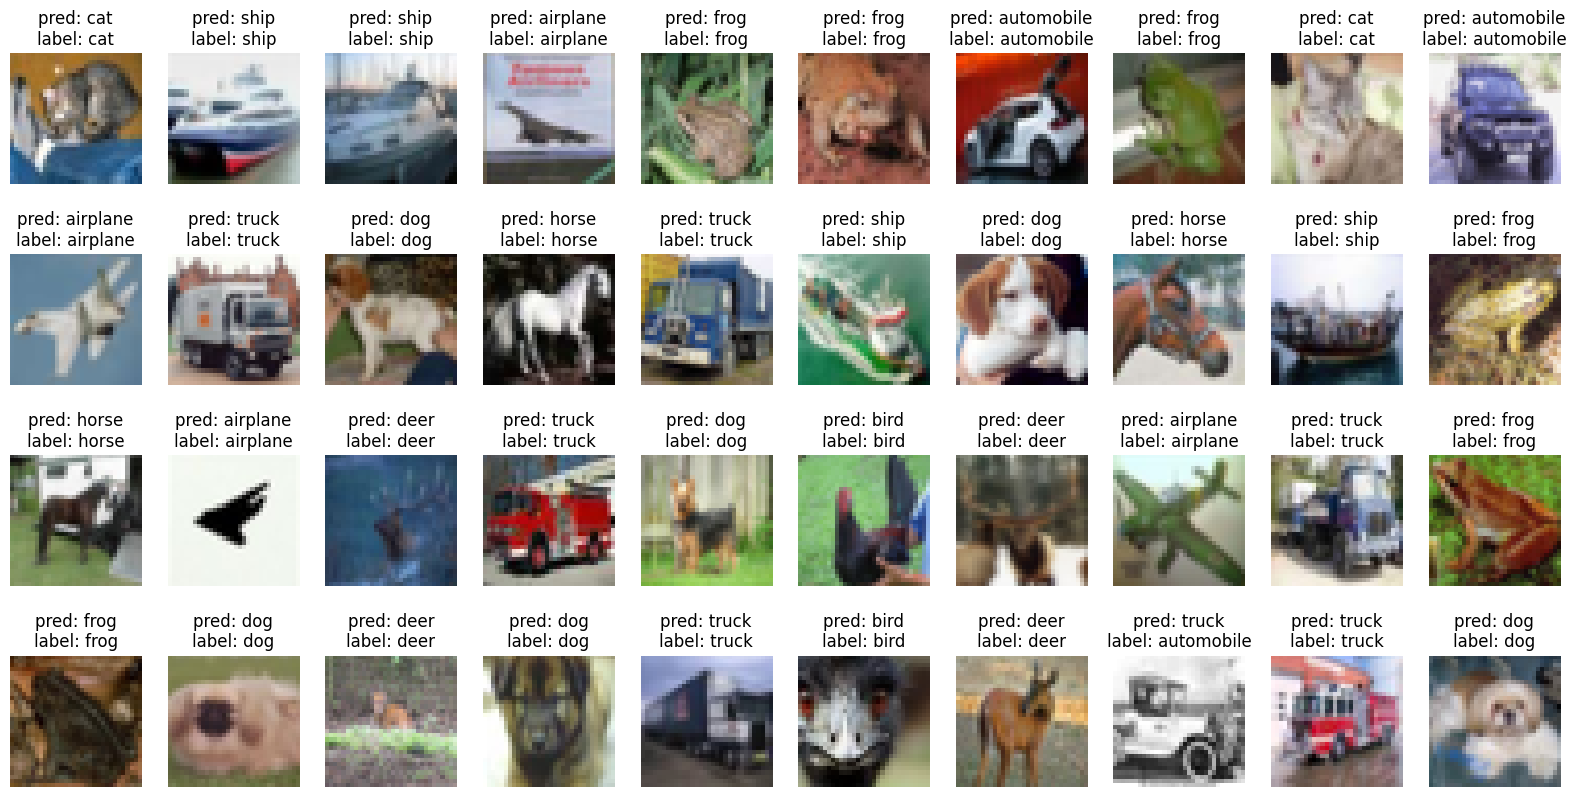

In [20]:
plt.figure(figsize=(20, 10))
for index in range(40):
  image, label = dataset["test"][index]

  # Model inference
  model.eval()
  with torch.inference_mode():
    pred = model(image.unsqueeze(dim=0).cuda())
    pred = pred.argmax(dim=1)

  # Convert from CHW to HWC for visualization
  image = image.permute(1, 2, 0)

  # Convert from class indices to class names
  pred = dataset["test"].classes[pred]
  label = dataset["test"].classes[label]

  # Visualize the image
  plt.subplot(4, 10, index + 1)
  plt.imshow(image)
  plt.title(f"pred: {pred}" + "\n" + f"label: {label}")
  plt.axis("off")
plt.show()